In [217]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [173]:
df = pd.read_csv('/content/House_Rent_Dataset.csv')

A glimpse of the datatset

In [174]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,5/18/2022,2,10000.0,1100.0,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,5/13/2022,2,20000.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,5/16/2022,2,17000.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,7/4/2022,2,10000.0,800.0,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,5/9/2022,2,7500.0,850.0,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4749 entries, 0 to 4748
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Posted On          4749 non-null   object 
 1   BHK                4749 non-null   int64  
 2   Rent               4745 non-null   float64
 3   Size               4745 non-null   float64
 4   Floor              4749 non-null   object 
 5   Area Type          4746 non-null   object 
 6   Area Locality      4747 non-null   object 
 7   City               4746 non-null   object 
 8   Furnishing Status  4749 non-null   object 
 9   Tenant Preferred   4749 non-null   object 
 10  Bathroom           4749 non-null   int64  
 11  Point of Contact   4749 non-null   object 
dtypes: float64(2), int64(2), object(8)
memory usage: 445.3+ KB


In [176]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4749.000000,4.745000e+03,4745.000000,4749.000000
mean,2.084439,3.503160e+04,967.712329,1.966519
std,0.832564,7.812978e+04,634.329629,0.884872
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [177]:
df.isnull().sum()

,0
Posted On,0
BHK,0
Rent,4
Size,4
Floor,0
Area Type,3
Area Locality,2
City,3
Furnishing Status,0
Tenant Preferred,0


In [178]:
df.duplicated().sum()

np.int64(3)

Data cleaning

In [179]:
df.drop_duplicates(inplace=True)

In [180]:
df.duplicated().sum()

np.int64(0)

In [181]:
df.dropna(inplace=True)

In [182]:
df.isnull().sum()

,0
Posted On,0
BHK,0
Rent,0
Size,0
Floor,0
Area Type,0
Area Locality,0
City,0
Furnishing Status,0
Tenant Preferred,0


In [183]:
df.drop('Posted On', axis=1, inplace = True )

In [184]:
df.head()

,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,10000.0,1100.0,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2,20000.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2,17000.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2,10000.0,800.0,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2,7500.0,850.0,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [185]:
le = LabelEncoder()

In [186]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# **Visualizing the data**
*to understand it better*

In [187]:
df.head()

,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,10000.0,1100.0,455,2,221,4,2,1,2,2
1,2,20000.0,800.0,14,2,1526,4,1,1,1,2
2,2,17000.0,1000.0,14,2,1757,4,1,1,1,2
3,2,10000.0,800.0,10,2,525,4,2,1,1,2
4,2,7500.0,850.0,10,1,1886,4,2,0,1,2


This means that there is and

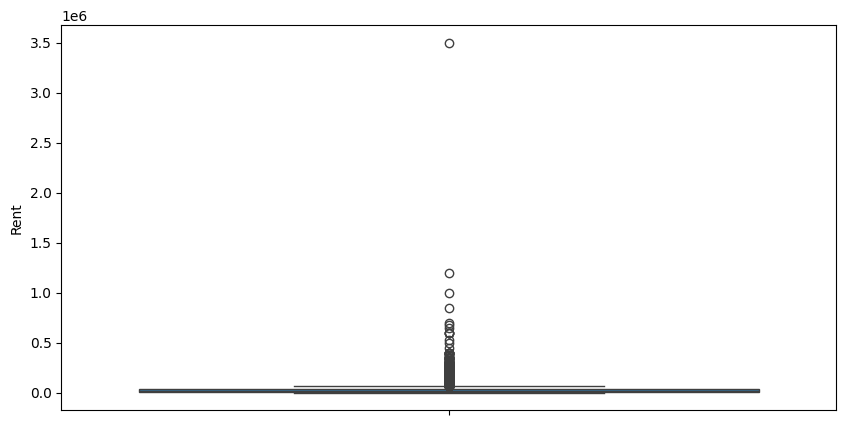

In [188]:
plt.figure(figsize=(10,5))
sns.boxplot(df['Rent'])
plt.show()

Removing the outlier

In [189]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define upper and lower bounds for outlier detection
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound (outliers below this): {lower_bound}")
print(f"Upper Bound (outliers above this): {upper_bound}")

Q1 (25th percentile): 10000.0
Q3 (75th percentile): 33000.0
IQR: 23000.0
Lower Bound (outliers below this): -24500.0
Upper Bound (outliers above this): 67500.0


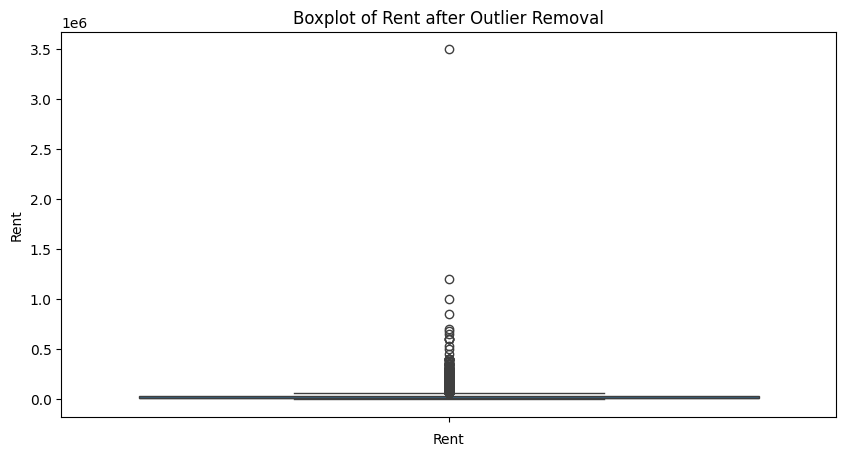

In [190]:
plt.figure(figsize=(10,5))
sns.boxplot(df['Rent'])
plt.title('Boxplot of Rent after Outlier Removal')
plt.xlabel('Rent')
plt.show()

Liner Regression

In [191]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [192]:
x = df.drop('Rent', axis=1)
y = df['Rent'] #?

In [193]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3)

In [194]:
lr = LinearRegression()

In [195]:
x_train.select_dtypes(include=['object']).columns

Index([], dtype='object')

In [196]:
lr.fit(x_train, y_train)


LinearRegression()

Mean Squared Error (MSE) and R-squared (R2) are both common metrics used to evaluate the performance of regression models:

Mean Squared Error (MSE): This metric measures the average of the squares of the errors (the difference between the actual values and the predicted values). A lower MSE indicates a better fit of the model to the data. It gives a relatively high weight to large errors, as the errors are squared.

R-squared (R2 Score): Also known as the coefficient of determination, R-squared represents the proportion of the variance in the dependent variable that can be predicted from the independent variables. It ranges from 0 to 1, where 1 indicates that the model perfectly predicts the target variable, and 0 indicates that the model explains none of the variability of the response data around its mean. A higher R-squared generally suggests a better model fit.

In [199]:
y_pred = lr.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 1694635817.2808573
R-squared: 0.4619922691782814


# **KNN**

In [200]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import KFold

In [202]:
from  sklearn.neighbors import KNeighborsClassifier

In [203]:
X = df.drop('Rent', axis=1)
y = df['Rent']

In [204]:
# Use the globally defined, preprocessed X and y (from label encoding step) for splitting
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X, y, test_size=0.2,random_state=42)

In [205]:
knn = KNeighborsClassifier(n_neighbors=3)

In [206]:
knn.fit(X_train_knn, y_train_knn)

KNeighborsClassifier(n_neighbors=3)

In [218]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred =knn.predict(x_test)
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [219]:
r2

0.21369707406577854

# **Random Forest**

In [220]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [223]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3)

In [224]:
ml = RandomForestClassifier(n_estimators= 100, random_state=42)

In [225]:
ml.fit(x_train, y_train)

RandomForestClassifier()

In [227]:
y_pred = ml.predict(x_test)

In [228]:
accuracy_score = accuracy_score(y_test, y_pred)*100

In [229]:
accuracy_score

9.020436927413671

In [230]:
y_pred =knn.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [231]:
r2

0.16143158177935513

# Task
Standardize the numerical features (excluding 'Rent') in the DataFrame using `StandardScaler`, split the data into training and testing sets, build a deep learning model using Keras `Sequential` with `Dense` layers, train the model, and then evaluate its performance using Mean Squared Error (MSE) and R-squared (R2).

## Standardize Features

### Subtask:
Standardize the numerical features (excluding 'Rent') using StandardScaler to prepare data for deep learning.


**Reasoning**:
To standardize the numerical features, I need to import StandardScaler, identify the numerical columns excluding 'Rent', initialize the scaler, apply it to the selected columns, and then update the DataFrame with the scaled values.



In [232]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to be scaled (excluding 'Rent')
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Rent' in numerical_cols:
    numerical_cols.remove('Rent')

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Numerical columns successfully standardized.")
print(df[numerical_cols].head())

Numerical columns successfully standardized.
        BHK      Size     Floor  Area Type  Area Locality      City  \
0 -0.100827  0.208155  1.387692   0.969188      -1.376102  0.866708   
1 -0.100827 -0.264339 -1.322550   0.969188       0.689719  0.866708   
2 -0.100827  0.050657 -1.322550   0.969188       1.055393  0.866708   
3 -0.100827 -0.264339 -1.347133   0.969188      -0.894869  0.866708   
4 -0.100827 -0.185590 -1.347133  -1.028310       1.259600  0.866708   

   Furnishing Status  Tenant Preferred  Bathroom  Point of Contact  
0           1.113705          0.144463  0.037266          0.689379  
1          -0.347956          0.144463 -1.092647          0.689379  
2          -0.347956          0.144463 -1.092647          0.689379  
3           1.113705          0.144463 -1.092647          0.689379  
4           1.113705         -1.785786 -1.092647          0.689379  


**Reasoning**:
The next step is to split the standardized data into training and testing sets to prepare for building and evaluating the deep learning model. I will define the features (X) as all columns except 'Rent' and the target (y) as the 'Rent' column, then use `train_test_split`.



In [233]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Rent', axis=1)
y = df['Rent']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data successfully split into training and testing sets.
X_train shape: (3784, 10)
X_test shape: (946, 10)
y_train shape: (3784,)
y_test shape: (946,)


**Reasoning**:
Now that the data is prepared (standardized and split), the next step is to build the deep learning model using Keras. This involves importing necessary Keras modules like `Sequential` and `Dense`, and then defining the architecture of the neural network.



In [234]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the deep learning model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # Output layer for regression (single numerical output)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_squared_error'])

print("Deep learning model built and compiled successfully.")
model.summary()

Deep learning model built and compiled successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
Now that the deep learning model is built and compiled, the next logical step is to train it using the training data (`X_train`, `y_train`) and then evaluate its performance on the test data (`X_test`, `y_test`) using Mean Squared Error and R-squared, as specified in the task.



In [235]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

y_pred_dl = model.predict(X_test)

mse_dl = mean_squared_error(y_test, y_pred_dl)
r2_dl = r2_score(y_test, y_pred_dl)

print(f"Deep Learning Model - Mean Squared Error: {mse_dl}")
print(f"Deep Learning Model - R-squared: {r2_dl}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Deep Learning Model - Mean Squared Error: 1611872473.2592175
Deep Learning Model - R-squared: 0.5280682036174361


## Summary:

### Data Analysis Key Findings

*   Numerical features (excluding 'Rent') were successfully standardized using `StandardScaler`.
*   The dataset was split into training and testing sets with an 80/20 ratio. For example, the training set for features had 3784 samples and 10 features (`X_train` shape: (3784, 10)).
*   A deep learning model with three `Dense` layers (64, 32, and 1 units) was built, compiled, and trained.
*   The deep learning model achieved a Mean Squared Error (MSE) of approximately 1,611,872,473.26 and an R-squared (\R^2$) value of 0.528 on the test set.

### Insights or Next Steps

*   The current R-squared value of 0.528 indicates that the model explains about 52.8\% of the variance in 'Rent', suggesting room for improvement. Further optimization through hyperparameter tuning (e.g., number of epochs, batch size, learning rate), adding more layers, or exploring different activation functions could enhance performance.
*   Given the relatively high MSE, it would be beneficial to investigate the residuals to understand where the model performs poorly. Additionally, exploring feature engineering or incorporating more relevant features might lead to a more robust model.
